# Weather Stations

A number of weather stations collect daily observations about atmospheric conditions in a region in order to provide data for weather forecasts and climate control. The file weather.csv contains atmospheric observations collected between 01/01/2022 and 30/05/2022 by 49 different stations spread across various locations in Piemonte, Italy. Observations are organized in a tabular way, with one row for each day.

In [1]:
from datetime import datetime
import numpy as np
import csv
import re
import matplotlib.pyplot as plt

# Constants used in the analysis
NUMBER_STATION = 49
WIDTH_DATA_STATION = 10
FEBRUARY_ROWS = 28
NUMBER_MONTH = 5

In [2]:
def identificator(first_row):              # function used in order to identify the ID of each station
    
    pattern = re.compile(r'\d+')
    identificator = np.zeros(NUMBER_STATION, dtype = int)
    extracted_number = [int(pattern.search(stringa).group()) if pattern.search(stringa) else None for stringa in first_row]
    k = 0
    
    for j in range(3,len(extracted_number),WIDTH_DATA_STATION):
        identificator[k] = extracted_number[j]
        k += 1
        
    return identificator
# We extract station identifiers from the header.


def data_matrix(pos, n_rows, n_columns, Dataset):           # function used for obtaining the specific matrix for each task
    
    data_matrix = np.zeros((n_rows, NUMBER_STATION))
    
    for i in range(n_rows):
        k=0
        for j in range(pos, n_columns, WIDTH_DATA_STATION):
            data_matrix[i,k] = Dataset[i,j]
            k +=1
            
    return data_matrix
# We obtain a specific matrix for each task.

## Task 1: 

Calculate the minimum, maximum and average rainfall and standard deviation of the rainfall over all the stations and all the days (a single set of numbers for the entire dataset).

## Task 2: 

Calculate the minimum, maximum and average rainfall and standard deviation of the rainfall at each station over all the days (a different set of numbers for each station).

## Task 3:

Calculate the minimum, maximum and average rainfall and standard deviation of the rainfall across all stations at each day (a different set of numbers for each day).

In [4]:
# TASK 1

def Rainfall(matrix_rainfall, n_rows):
    # Function to calculate minimum, maximum, average, and standard deviation of rainfall over all stations and days
    
    vector_rainfall = matrix_rainfall.reshape(-1)
    tot_rain = (np.min(vector_rainfall), np.max(vector_rainfall), np.mean(vector_rainfall), np.std(vector_rainfall))

    # we obtain the set of numbers of rainfall for the entire dataset 
    
# TASK 2

    matrix_station_rain = np.zeros((4,NUMBER_STATION))
    
    for k in range(NUMBER_STATION):
        # each column of the matrix corresponds to a particular station
        matrix_station_rain[0,k] = np.min(matrix_rainfall[:,k])
        matrix_station_rain[1,k] = np.max(matrix_rainfall[:,k])
        matrix_station_rain[2,k] = np.mean(matrix_rainfall[:,k])
        matrix_station_rain[3,k] = np.std(matrix_rainfall[:,k])

    matrix_station_rain = matrix_station_rain.T
    
    # we obtain a set of numbers of rainfall for each station in a matrix of dimension (49 x 4) in this case
    
# TASK 3
    
    matrix_day_rain = np.zeros((n_rows,4))
    
    for i in range(n_rows):
        # each row of the matrix corresponds to a particular day
        matrix_day_rain[i,0] = np.min(matrix_rainfall[i,:])
        matrix_day_rain[i,1] = np.max(matrix_rainfall[i,:])
        matrix_day_rain[i,2] = np.mean(matrix_rainfall[i,:])
        matrix_day_rain[i,3] = np.std(matrix_rainfall[i,:])
        
    # we obtain a set of numbers of rainfall for each day in a matrix of dimension (n_rows x 4) in this case
    
    return np.round(tot_rain,3), np.round(matrix_station_rain,3), np.round(matrix_day_rain,3)

## TASK 4:

Find the station that registered the highest temperature on each day (a station id for each day).

In [5]:
# TASK 4

def Highest_Temperature(identificat, matrix_high_temp, n_rows):
    # Function to find the station with the highest temperature for each day

    id_day_HT = [] # List to store the station id with the highest temperature for each day
    
    for i in range(n_rows):
        maxim = np.argwhere(matrix_high_temp[i,:] == np.max(matrix_high_temp[i,:]))
        id_day_HT.append([identificat[int(item)] for item in maxim])
    
    return id_day_HT
# We find the station with the highest temperature for each day.

## TASK 5:

Find the day in which the lowest temperature has been recorded.

In [6]:
# TASK 5

def Lowest_temp_day(matrix_low_temp, Dataset):
    # Function to find the day with the lowest temperature

    
    coord_min = np.unravel_index(np.argmin(matrix_low_temp), matrix_low_temp.shape)     # we find coordinates of minimum in 2D
    data = datetime(int(Dataset[coord_min[0],0]), int(Dataset[coord_min[0],1]), int(Dataset[coord_min[0],2]))
    
    return data
# We obtain the day with the lowest temperature.

## TASK 6:

Find the average relative humidity recorded in February for each station.

In [8]:
def rows(n_rows, Dataset):
    # Helper function to get the rows corresponding to February in the dataset
    
    february_rows = np.zeros(FEBRUARY_ROWS, dtype = int)
    k=0
    for i in range(n_rows):
        if (Dataset[i,1] == 2):  # Check if the month is February
            february_rows[k] = i
            k += 1
            
    return february_rows
# We obtain the rows corresponding to the month of February.


# TASK 6

def Rel_Hum(february_rows, n_columns, Dataset):
    # Function to calculate average relative humidity for each station in February

    matrix_Mean_RelHum = np.zeros((FEBRUARY_ROWS, NUMBER_STATION))
    matrix_Max_RelHum = np.zeros((FEBRUARY_ROWS, NUMBER_STATION))
    matrix_Min_RelHum = np.zeros((FEBRUARY_ROWS, NUMBER_STATION))
    
    n=0
    for i in range(int(february_rows[0]),int(february_rows[-1])+1):
        k=0
        for j in range(8, n_columns, WIDTH_DATA_STATION):
            matrix_Mean_RelHum[n,k] = Dataset[i,j]
            matrix_Min_RelHum[n,k] = Dataset[i,j-1]
            matrix_Max_RelHum[n,k] = Dataset[i,j-2]
            k +=1
        n +=1
        
    vector_Mean_RelHum = np.zeros(NUMBER_STATION)
    vector_Max_RelHum = np.zeros(NUMBER_STATION)
    vector_Min_RelHum = np.zeros(NUMBER_STATION)

    for k in range(NUMBER_STATION):
        vector_Mean_RelHum[k] = np.mean(matrix_Mean_RelHum[:,k])
        vector_Max_RelHum[k] = np.mean(matrix_Max_RelHum[:,k])
        vector_Min_RelHum[k] = np.mean(matrix_Min_RelHum[:,k])
    
    return np.round(vector_Mean_RelHum,3), np.round(vector_Max_RelHum,3), np.round(vector_Min_RelHum,3)
# We obtain the average, maximum, and minimum relative humidity for each station in February.

## TASK 7:

Calculate the average relative humidity for each month in the dataset.

In [9]:
# TASK 7

def Average_Month(n_rows, n_columns, pos, Dataset):
    # Function to calculate the average relative humidity for each month

    average_month_vector = np.zeros(NUMBER_MONTH)
    current_month = 1
    days = 0

    for i in range(n_rows):
        if (Dataset[i,1] == current_month):
            lista=[]
            days +=1
            for j in range(pos, n_columns, WIDTH_DATA_STATION):
                lista.append(Dataset[i,j])
            average_month_vector[current_month-1] += (sum(lista))/NUMBER_STATION
                
        if ((i < n_rows-1) and (Dataset[i+1,1] == current_month + 1)):
            average_month_vector[current_month-1] = average_month_vector[current_month-1]/(days)
            current_month += 1
            days = 0
            continue
            
        if (i == n_rows-1):
            average_month_vector[current_month-1] = average_month_vector[current_month-1]/(days)
            break
            
    return np.round(average_month_vector,3)   
# We obtain the average relative humidity for each month in the dataset.

## TASK 8:

Compute the monthly average of daily temperature ranges across all stations. Visualize them as a bar plot.

In [10]:
# TASK 8: Visualize the monthly average of daily temperature ranges across all stations as a bar plot.

def barplot(minim, median, maxim):
    # Function to visualize the monthly average of daily temperature ranges as a bar plot
    
    categories = ['January', 'February', 'March', 'April', 'May']
    fig, ax = plt.subplots()
    plt.figure(figsize=(14, 10))
    for i, category in enumerate(categories):
        ax.vlines(i, minim[i], maxim[i], color='grey', linewidth=10)
        ax.hlines(median[i], i - 0.2, i + 0.2, color='black', linewidth=3)
        
        ax.annotate(f'{minim[i]}°', (i + 0.25, minim[i]), ha='center', va='bottom', color='blue',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize=8)

        ax.annotate(f'{maxim[i]}°', (i + 0.25, maxim[i]), ha='center', va='top', color='red',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize=8)

        ax.annotate(f'{median[i]}°', (i + 0.25, median[i]), ha='center', va='bottom', color='black',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5), fontsize=8)


    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories)
    ax.set_ylabel('Temperature ranges')
    ax.set_title('Monthly Average Temperatures Barplot')
    plt.show()
# We obtain a bar plot visualizing the monthly average of daily temperature ranges across all stations.

## Main Function 

In [11]:
def main():
    # Read the data from the CSV file into a NumPy array
    
    with open('weather.csv', 'r') as file_csv:
        csv_reader = csv.reader(file_csv) 
        first_row = next(csv_reader)  # read the first row
        Dataset  = np.array([riga for riga in csv_reader], dtype=np.float32)
        n_columns = np.shape(Dataset)[1]
        n_rows = np.shape(Dataset)[0]
    
    # Extract station identities from the header
    identities =identificator(first_row)
    
    # Extract rainfall data and perform computations
    matrix_rainfall = data_matrix(12, n_rows, n_columns, Dataset)     # for rainfall we start to look at 13th colummn (12 in python)
    ts1, ts2, ts3 = Rainfall(matrix_rainfall, n_rows)
    print(f"1. Minimum, Maximum, Average and Standard Deviation Rainfall over all the stations and all the days:\n")
    print(f"{ts1}")
    print(f"\n")
    
    print(f"2. Minimum, Maximum, Average and Standard Deviation Rainfall at each station over all the days: \n ")
    for i in range(len(identities)):
        print(f"Station-id {identities[i]}: {ts2[i]}")
    print(f"\n")
    
    print(f"3. Minimum, Maximum, Average and Standard Deviation Rainfall across all stations at each day : \n ")
    for i in range(n_rows):
        date = datetime(int(Dataset[i,0]), int(Dataset[i,1]), int(Dataset[i,2]))
        print(f"Day {date.strftime('%d-%m-%Y')}: {ts3[i]}")
    print(f"\n")
    
    # Extract highest temperature data and find stations with the highest temperature on each day
    matrix_high_temp = data_matrix(3, n_rows, n_columns, Dataset)     # for the highest temperature we start to look at 4th colummn (3 in python)
    id_day_HT = Highest_Temperature(identities, matrix_high_temp, n_rows)
    
    # Print results for stations with the highest temperature on each day
    print(f"4. Station that registered the highest temperature on each day : \n ")
    for i in range(n_rows):
        date = datetime(int(Dataset[i,0]), int(Dataset[i,1]), int(Dataset[i,2]))
        print(f"Day {date.strftime('%d-%m-%Y')}: {id_day_HT[i]}")
    print(f"\n")
    
    # Extract lowest temperature data and find the day with the lowest temperature
    matrix_low_temp = data_matrix(4, n_rows, n_columns, Dataset)  # for the lowest temperature we start to look at 5th colummn (4 in python)
    data = Lowest_temp_day(matrix_low_temp, Dataset)
    # Print result for the day with the lowest temperature
    print(f"5. Day with the lowest temperature : \n ")
    print(f"Day : {data.strftime('%d-%m-%Y')}")
    print(f"\n")
    
    # Extract data for February and compute average relative humidity
    february_rows = rows(n_rows, Dataset)
    v_Mean_RelHum, v_Max_RelHum, v_Min_RelHum = Rel_Hum(february_rows, n_columns, Dataset)
    # Print results for average relative humidity in February
    print(f"6. Average Relative Humidity recorded in February for each station : \n ")
    for i in range(len(identities)):
        print(f"Station-id {identities[i]}: Mean Relative Humidity: {v_Mean_RelHum[i]}, Maximum Relative Humidity: {v_Max_RelHum[i]}, Minimum Relative Humidity: {v_Min_RelHum[i]},")
    print(f"\n")
    
    # Compute average relative humidity for each month in the dataset
    aver_month_hum = Average_Month(n_rows, n_columns, 8, Dataset)       # for the humidity we start to look at 9th colummn (8 in python)
    max_aver_month_hum = Average_Month(n_rows, n_columns, 6, Dataset)   # for the max humidity we start to look at 7th colummn (6 in python)
    min_aver_month_hum = Average_Month(n_rows, n_columns, 7, Dataset)   # for the min humidity we start to look at 8th colummn (7 in python)
    # Print results for average relative humidity for each month
    print(f"7. Average Relative Humidity for each month in the dataset : \n ")
    for i in range(len(aver_month_hum)):
        print(f"Month {i+1}: Mean Relative Humidity: {aver_month_hum[i]}, Maximum Relative Humidity: {max_aver_month_hum[i]}, Minimum Relative Humidity: {min_aver_month_hum[i]},")
    print(f"\n")
    
    # Compute monthly average of daily temperature ranges across all stations
    average_month_maxT = Average_Month(n_rows, n_columns, 3, Dataset)        # for the max temperature we start to look at 4th colummn (3 in python)
    average_month_minT = Average_Month(n_rows, n_columns, 4, Dataset)        # for the min temperature we start to look at 5th colummn (4 in python)
    average_month_meanT = Average_Month(n_rows, n_columns, 5, Dataset)       # for the mean temperature we start to look at 6th colummn (5 in python)
    # Print results for monthly average of daily temperature ranges across all stations
    print(f"8. Monthly Average of daily Temperature Ranges across all stations. : \n ")
    for i in range(len(average_month_maxT)):
        print(f"Month {i+1}: Mean Temperature: {average_month_meanT[i]}, Maximum Temperature: {average_month_maxT[i]}, Minimum Temperature: {average_month_minT[i]},")
    barplot(average_month_minT, average_month_meanT, average_month_maxT)

1. Minimum, Maximum, Average and Standard Deviation Rainfall over all the stations and all the days:

[  0.    110.8     1.232   5.024]


2. Minimum, Maximum, Average and Standard Deviation Rainfall at each station over all the days: 
 
Station-id 1: [ 0.    13.4    0.634  2.025]
Station-id 130: [0.    9.    0.432 1.374]
Station-id 5: [ 0.    28.8    1.364  4.802]
Station-id 10: [ 0.    19.     0.887  2.818]
Station-id 140: [ 0.    79.2    2.142  7.75 ]
Station-id 142: [ 0.    28.2    1.029  3.486]
Station-id 143: [ 0.    26.     0.776  2.796]
Station-id 145: [ 0.    27.     0.601  2.617]
Station-id 21: [ 0.    29.8    1.281  3.819]
Station-id 22: [ 0.    30.     0.53   2.638]
Station-id 151: [ 0.    15.6    0.554  1.698]
Station-id 24: [ 0.    30.6    0.792  3.415]
Station-id 152: [ 0.    31.     0.97   3.246]
Station-id 154: [ 0.    14.4    0.901  2.159]
Station-id 28: [ 0.    19.8    1.589  4.301]
Station-id 29: [ 0.    49.4    1.685  6.106]
Station-id 156: [ 0.    57.7    0.787  4.

C:\Users\Davide\AppData\Local\Temp\ipykernel_20952\4139622693.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  id_day_HT.append([identificat[int(item)] for item in maxim])


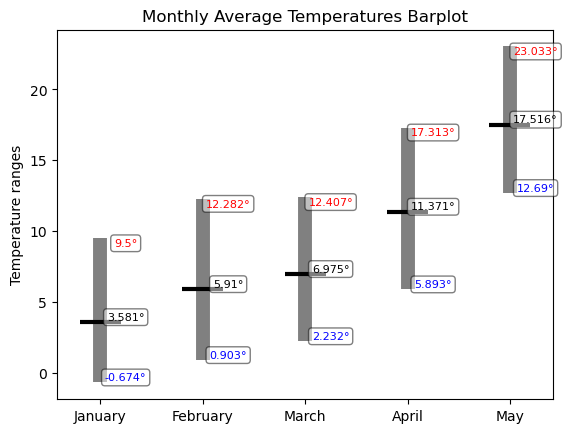

<Figure size 1400x1000 with 0 Axes>

In [12]:
# Main function to execute the program
if __name__ == "__main__":
    main()